In [2]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
#Read_csv
df_credit = pd.read_csv(r"C:/Users/vince/Documents/Data Analytics Portfolio/Project-1-credit-card/Data/cc_dataset.csv")

In [4]:
df_credit.head()

,cc_num,gender,city,city_pop,job,dob,acct_num,acct_num2,trans_num,unix_time,category,amt
0,2.440000e+15,Male,Masbate,"95,389 people",Social worker,20/09/1961,7.860000e+11,786000000000,796378571728737b9c6fb9bce743f0b7,1585037558,gas_transport,$82.84
1,4.090000e+15,Male,Muntinlupa City,"504,509 people",Industrial/product designer,12/04/1938,7.220000e+11,722000000000,f19c0e584c1fd59bc115b74e20f40778,1635789315,home,$56.00
2,3.520000e+15,Male,Digos,"169,393 people","Administrator, charities/voluntary organisations",31/08/1970,9.680000e+11,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,1622173127,gas_transport,$42.71
3,4.730000e+15,M,Vigan,"53,879 people","Geologist, engineering",28/05/1945,2.270000e+11,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,1593208228,personal_care,$48.26
4,3.710000e+14,F,Maasin,"85,560 people","Engineer, site",18/04/1966,9.940000e+11,994000000000,249ed34cd0370bf77e579955654548d6,1589503270,entertainment,$8.18


In [5]:
df_credit.shape

(70000, 12)

In [6]:
df_credit.describe()

,cc_num,acct_num,acct_num2,unix_time
count,7.000000e+04,6.469300e+04,7.000000e+04,7.000000e+04
mean,3.742948e+17,6.048400e+11,5.724669e+11,1.609157e+09
std,1.228158e+18,2.684263e+11,2.893750e+11,1.719883e+07
min,6.049060e+10,1.240000e+11,3.843261e+09,1.577839e+09
25%,3.800000e+13,3.843000e+11,2.980000e+11,1.594460e+09
50%,3.520000e+15,5.870000e+11,5.810000e+11,1.608345e+09
75%,4.620000e+15,8.510000e+11,8.450000e+11,1.624396e+09
max,4.830000e+18,9.964000e+11,9.940000e+11,1.638835e+09


In [7]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cc_num     70000 non-null  float64
 1   gender     70000 non-null  object 
 2   city       70000 non-null  object 
 3   city_pop   70000 non-null  object 
 4   job        64693 non-null  object 
 5   dob        70000 non-null  object 
 6   acct_num   64693 non-null  float64
 7   acct_num2  70000 non-null  int64  
 8   trans_num  70000 non-null  object 
 9   unix_time  70000 non-null  int64  
 10  category   64680 non-null  object 
 11  amt        70000 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 6.4+ MB


**Base on the initial checking of information:** <br>
-> acct_num: missing values but acct_num = acct_num2  <br>
-> Job : missing values , will impute unknown or will drop it since will bucket the type of job later on <br>
-> Category : Impute "Others" to the NA

# Data Processing

In [8]:
# Check if there are duplicated rows and keep only the first instance
df_credit.duplicated().sum()
df_credit.drop_duplicates(inplace = True)

In [9]:
# Remove acct_numm, acct_num = acct_num2
df_credit.drop(columns = "acct_num", inplace = True)

In [10]:
df_credit.rename(columns = {"acct_num2": "Acc_Number"}, inplace = True)

In [11]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cc_num      70000 non-null  float64
 1   gender      70000 non-null  object 
 2   city        70000 non-null  object 
 3   city_pop    70000 non-null  object 
 4   job         64693 non-null  object 
 5   dob         70000 non-null  object 
 6   Acc_Number  70000 non-null  int64  
 7   trans_num   70000 non-null  object 
 8   unix_time   70000 non-null  int64  
 9   category    64680 non-null  object 
 10  amt         70000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 5.9+ MB


In [12]:
df_credit["Transaction_date"] = pd.to_datetime(df_credit["unix_time"], unit = 's',  utc = True)
df_credit["Transaction_date"] = df_credit["Transaction_date"].dt.tz_convert("Asia/Manila")
df_credit["Transaction_date"] = df_credit["Transaction_date"].dt.strftime("%Y-%m-%d %H:%M:%S")
df_credit.drop(columns = ["unix_time"], inplace = True)
df_credit.head()

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,amt,Transaction_date
0,2.440000e+15,Male,Masbate,"95,389 people",Social worker,20/09/1961,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,$82.84,2020-03-24 16:12:38
1,4.090000e+15,Male,Muntinlupa City,"504,509 people",Industrial/product designer,12/04/1938,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,$56.00,2021-11-02 01:55:15
2,3.520000e+15,Male,Digos,"169,393 people","Administrator, charities/voluntary organisations",31/08/1970,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,$42.71,2021-05-28 11:38:47
3,4.730000e+15,M,Vigan,"53,879 people","Geologist, engineering",28/05/1945,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,$48.26,2020-06-27 05:50:28
4,3.710000e+14,F,Maasin,"85,560 people","Engineer, site",18/04/1966,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,$8.18,2020-05-15 08:41:10


In [13]:
df_credit['city_pop'] = df_credit['city_pop'].str.replace(" people","").str.replace(",","").astype(int)
df_credit.head()

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,amt,Transaction_date
0,2.440000e+15,Male,Masbate,95389,Social worker,20/09/1961,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,$82.84,2020-03-24 16:12:38
1,4.090000e+15,Male,Muntinlupa City,504509,Industrial/product designer,12/04/1938,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,$56.00,2021-11-02 01:55:15
2,3.520000e+15,Male,Digos,169393,"Administrator, charities/voluntary organisations",31/08/1970,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,$42.71,2021-05-28 11:38:47
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",28/05/1945,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,$48.26,2020-06-27 05:50:28
4,3.710000e+14,F,Maasin,85560,"Engineer, site",18/04/1966,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,$8.18,2020-05-15 08:41:10


In [14]:
df_credit['amt_USD'] = df_credit['amt'].str.replace("$","").astype(float)
df_credit.drop(columns = ["amt"], inplace = True)
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD
0,2.440000e+15,Male,Masbate,95389,Social worker,20/09/1961,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84
1,4.090000e+15,Male,Muntinlupa City,504509,Industrial/product designer,12/04/1938,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00
2,3.520000e+15,Male,Digos,169393,"Administrator, charities/voluntary organisations",31/08/1970,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",28/05/1945,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26
4,3.710000e+14,F,Maasin,85560,"Engineer, site",18/04/1966,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18
...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",08/02/1960,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,25/10/1949,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,11/01/1966,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31
69998,3.470000e+14,Male,Pagadian,199060,General practice doctor,06/12/1949,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28


In [15]:
# Checking gender values, 4 unique values -> will use M = Male , F = Female
df_credit["gender"].unique()
df_credit["gender"].value_counts()

# Replace 'Male' and 'Female' in `gender` by 'M' and 'F'
gender_map = {
        "Male" : "M",
        "M" : "M",
        "Female" : "F",
        "F" : "F"}

df_credit["gender"] = df_credit["gender"].map(gender_map)
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD
0,2.440000e+15,M,Masbate,95389,Social worker,20/09/1961,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84
1,4.090000e+15,M,Muntinlupa City,504509,Industrial/product designer,12/04/1938,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00
2,3.520000e+15,M,Digos,169393,"Administrator, charities/voluntary organisations",31/08/1970,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",28/05/1945,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26
4,3.710000e+14,F,Maasin,85560,"Engineer, site",18/04/1966,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18
...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",08/02/1960,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,25/10/1949,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,11/01/1966,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31
69998,3.470000e+14,M,Pagadian,199060,General practice doctor,06/12/1949,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28


# Adding Age Column

In [16]:
# Add Age of the Holder
df_credit["dob"] = pd.to_datetime(df_credit["dob"], format = 'mixed')
current_time = pd.Timestamp.now()
df_credit["Age"] = (current_time - df_credit["dob"])//pd.Timedelta(days = 365)

In [17]:
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD,Age
0,2.440000e+15,M,Masbate,95389,Social worker,1961-09-20,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84,64
1,4.090000e+15,M,Muntinlupa City,504509,Industrial/product designer,1938-12-04,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00,87
2,3.520000e+15,M,Digos,169393,"Administrator, charities/voluntary organisations",1970-08-31,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71,55
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",1945-05-28,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26,81
4,3.710000e+14,F,Maasin,85560,"Engineer, site",1966-04-18,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18,60
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",1960-08-02,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54,65
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,1949-10-25,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89,76
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,1966-11-01,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31,59
69998,3.470000e+14,M,Pagadian,199060,General practice doctor,1949-06-12,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28,77


In [18]:
# Create age bin for 0-20, 20-40, 40-60, 60-80, 80-100
df_credit["Age_Bin"] = pd.cut(df_credit["Age"], bins = [0, 30, 50, 70, 90, 100], labels = ["0-30", "30-50", "50-70", "70-90", "90-100"])
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD,Age,Age_Bin
0,2.440000e+15,M,Masbate,95389,Social worker,1961-09-20,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84,64,50-70
1,4.090000e+15,M,Muntinlupa City,504509,Industrial/product designer,1938-12-04,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00,87,70-90
2,3.520000e+15,M,Digos,169393,"Administrator, charities/voluntary organisations",1970-08-31,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71,55,50-70
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",1945-05-28,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26,81,70-90
4,3.710000e+14,F,Maasin,85560,"Engineer, site",1966-04-18,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18,60,50-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",1960-08-02,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54,65,50-70
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,1949-10-25,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89,76,70-90
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,1966-11-01,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31,59,50-70
69998,3.470000e+14,M,Pagadian,199060,General practice doctor,1949-06-12,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28,77,70-90


# Exploring Missing Values

In [19]:
# Count Missing Values per Column
missing_values_count = df_credit.isnull().sum()
print(f"Missing Value Per Column:")
print(f"{missing_values_count}\n")

Missing Value Per Column:
cc_num                 0
gender                 0
city                   0
city_pop               0
job                 5307
dob                    0
Acc_Number             0
trans_num              0
category            5320
Transaction_date       0
amt_USD                0
Age                    0
Age_Bin                0
dtype: int64



In [20]:
# Calculate Percentage of Missing Values in whole data set
print(f"Size of Data Set: {df_credit.size}")
print(f"Sum of Missing Value in Data Set: {missing_values_count.sum()}")
percentage_missing = (missing_values_count.sum() / df_credit.size) * 100
print(f"Percentage of Missing Value: {percentage_missing:.2f}%")

Size of Data Set: 910000
Sum of Missing Value in Data Set: 10627
Percentage of Missing Value: 1.17%


In [21]:
# Separate Numerical & Categorical Columns
#numerical_columns = df_credit.columns[df_credit.dtypes != 'object']
numerical_columns = df_credit.select_dtypes(include = 'number')
numerical_columns

,cc_num,city_pop,Acc_Number,amt_USD,Age
0,2.440000e+15,95389,786000000000,82.84,64
1,4.090000e+15,504509,722000000000,56.00,87
2,3.520000e+15,169393,968000000000,42.71,55
3,4.730000e+15,53879,227000000000,48.26,81
4,3.710000e+14,85560,994000000000,8.18,60
...,...,...,...,...,...
69995,2.320000e+15,333028,664000000000,8.54,65
69996,3.540000e+15,302231,432000000000,8.89,76
69997,4.010000e+12,174625,439000000000,12.31,59
69998,3.470000e+14,199060,289000000000,4.28,77


In [22]:
# Separate Numerical & Categorical Columns
#numerical_columns = df_credit.columns[df_credit.dtypes != 'object']
categorical_columns = df_credit.select_dtypes(include = 'object')
categorical_columns

,gender,city,job,trans_num,category,Transaction_date
0,M,Masbate,Social worker,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38
1,M,Muntinlupa City,Industrial/product designer,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15
2,M,Digos,"Administrator, charities/voluntary organisations",6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47
3,M,Vigan,"Geologist, engineering",e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28
4,F,Maasin,"Engineer, site",249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10
...,...,...,...,...,...,...
69995,M,Binan,"Teacher, early years/pre",99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42
69996,M,Cabanatuan City,Engineering geologist,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40
69997,M,Malaybalay,Tourist information centre manager,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08
69998,M,Pagadian,General practice doctor,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37


## Handling Missing Values

#### **Handling Missing Values: Numerical**

#### **Handling Missing Values: Categorical**

In [23]:
# Will Separately handle categorical data

categorical_values_count = categorical_columns.isnull().sum()

categorical_with_missing = categorical_values_count[categorical_values_count > 0]

print(f"For this project will follow the rule of thumb of:")
print(f" - Less than 5% missing → Fill with most common/median value")
print(f" - More than 5% missing → Consider removing those rows or columns.\n")

if len(categorical_with_missing) > 0:
    for column, value in categorical_with_missing.items():
        percent_missing = (value / len(df_credit)) * 100
        print(f" {column}: {value} missing ({percent_missing:.2f}%) of data")

        # Will handle the missing values at this part and will follow the rule of thumb
        if percent_missing < 5:
            df_credit.fillna("Others", inplace = True)
            print(f' column: {column} - filled NA with "Others"')

        else:
            df_credit = df_credit.dropna(subset = column) # Used subset to specify column where to drop

For this project will follow the rule of thumb of:
 - Less than 5% missing → Fill with most common/median value
 - More than 5% missing → Consider removing those rows or columns.

 job: 5307 missing (7.58%) of data
 category: 5320 missing (8.22%) of data


In [24]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59764 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   cc_num            59764 non-null  float64       
 1   gender            59764 non-null  object        
 2   city              59764 non-null  object        
 3   city_pop          59764 non-null  int64         
 4   job               59764 non-null  object        
 5   dob               59764 non-null  datetime64[ns]
 6   Acc_Number        59764 non-null  int64         
 7   trans_num         59764 non-null  object        
 8   category          59764 non-null  object        
 9   Transaction_date  59764 non-null  object        
 10  amt_USD           59764 non-null  float64       
 11  Age               59764 non-null  int64         
 12  Age_Bin           59764 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 

In [25]:
# Final Check for Cleaning
print("Final Shape", df_credit.shape)
print(f"Remaining nulls: {df_credit.isnull().sum().sum()}")

Final Shape (59764, 13)
Remaining nulls: 0


In [26]:
df_credit["cc_num"].nunique()

69

# Exploratory Data Analysis

## Customer Analysis

### Gender Distrtibution

In [27]:
#gender = df_credit["gender"].value_counts()
#gender["Percent %"] = gender

In [28]:
gender = df_credit.groupby("Acc_Number")["gender"].first().value_counts().reset_index()
gender.columns = ["Gender", "Count"]
gender["Percentage"] = ((gender["Count"]/gender["Count"].sum()) * 100).round(1)                                          
gender.head()

,Gender,Count,Percentage
0,M,84,94.4
1,F,5,5.6


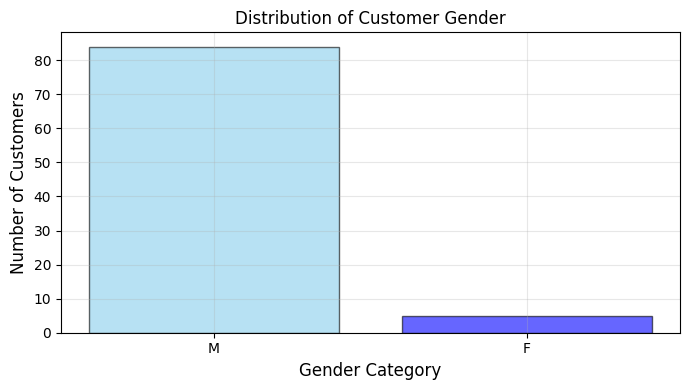

In [29]:
# Visualize Gender
# To answer how many of the customers are male and female

plt.figure(figsize = (7,4))
plt.bar(gender["Gender"], gender["Count"], color = ["skyblue", "blue"], alpha = 0.6, edgecolor = "black")
plt.title("Distribution of Customer Gender", fontsize = 12)
plt.xlabel("Gender Category", fontsize = 12)
plt.ylabel("Number of Customers", fontsize = 12)
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

Key points: 

- Total of 89 Card holders.
- Male Card holder dominates the total customer having a 94.4% againts a 5.6% Female Card Holders


In [30]:
# Distribution of Age

Age_df = df_credit.groupby("Acc_Number")[["Age","Age_Bin"]].first().reset_index()
Age_df.columns = ["Acc_Num", "Age", "Age_Bin"]
Age_df

,Acc_Num,Age,Age_Bin
0,3843260959,66,50-70
1,20386303916,61,50-70
2,24058295524,77,70-90
3,34614744133,70,50-70
4,38399733986,81,70-90
...,...,...,...
84,968000000000,55,50-70
85,969000000000,66,50-70
86,971000000000,84,70-90
87,989000000000,77,70-90


In [54]:
count_age = df_credit.groupby("Acc_Number")["Age"].first().value_counts().reset_index()
count_age.head(5)

,Age,count
0,77,7
1,64,5
2,56,5
3,71,5
4,69,4


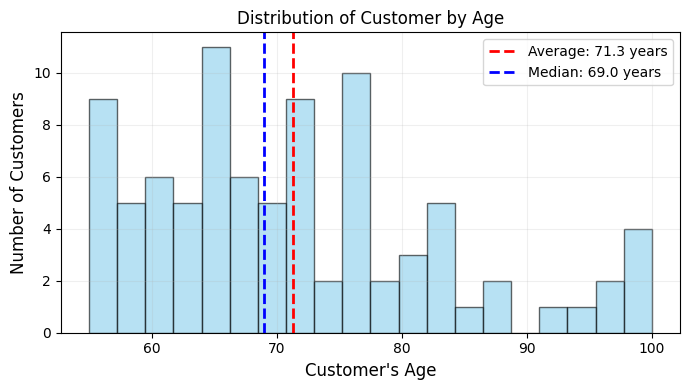

In [33]:
# Visualize Age Distribution
# To answer in what age does our customer falls

plt.figure(figsize = (7,4))
plt.hist(Age_df["Age"], bins = 20, color = "skyblue", alpha = 0.6, edgecolor = "black")
plt.title("Distribution of Customer by Age", fontsize = 12)
plt.xlabel("Customer's Age", fontsize = 12)
plt.ylabel("Number of Customers", fontsize = 12)
plt.grid(True, alpha = 0.2)

# Helpful statistics to plot
plt.axvline(Age_df["Age"].mean(), color = "red", linestyle = "--", linewidth = 2, label = f"Average: {Age_df["Age"].mean():.1f} years")
plt.axvline(Age_df["Age"].median(), color = "blue", linestyle = "--", linewidth = 2, label = f"Median: {Age_df["Age"].median():.1f} years")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
bin_age = df_credit.groupby("Acc_Number")["Age_Bin"].first().value_counts().reset_index()
bin_age

Key Points:

- Distribution of Age ranges from around 50 to 100
- Average of age at 71.3 Y/O and 69 Y/O as the median.

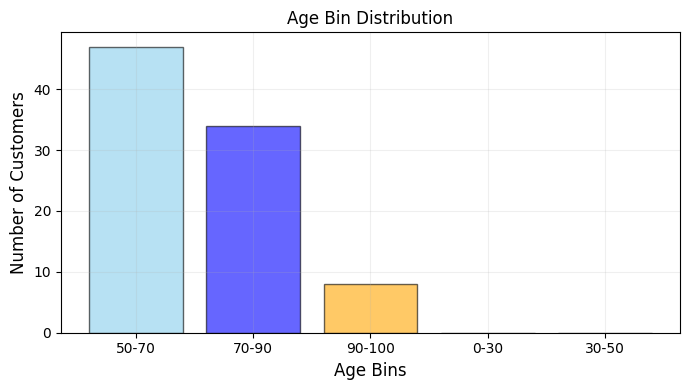

In [34]:
# Visualize Age bin Distribution 

plt.figure(figsize = (7,4))
plt.bar(bin_age["Age_Bin"], bin_age["count"], color = ["skyblue", "Blue", "Orange"], alpha = 0.6, edgecolor = "black")
plt.title("Age Bin Distribution", fontsize = 12)
plt.xlabel("Age Bins", fontsize = 12)
plt.ylabel("Number of Customers", fontsize = 12)
plt.grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()


Key Points:

- Dominantly card holder mostly from age group of 50-70 Years Old, having the highest count of customers
- There is no card holders from 20 to 50 Years Old

In [35]:
cities = df_credit["city"].value_counts()
cities

city
San Fernando          3837
Cadiz                 2965
Calapan               2958
Masbate               2896
Dasmarinas            2571
Pagadian              2135
Malaybalay            2119
Olongapo              2107
Dumaguete City        1691
Makati City           1296
Mati                  1289
City of Calamba       1287
Naga City             1283
Binan                 1282
Tacloban              1282
Butuan                1277
Sorsogon              1268
Muntinlupa City       1267
City of Isabela       1266
Meycauayan            1266
Laoag                 1259
Digos                 1247
Angeles City          1244
Tagbilaran City       1239
Santa Rosa            1239
Malabon               1231
Batangas              1227
Palayan City           872
Maasin                 858
Puerto Princesa        854
Vigan                  852
City of Paranaque      850
Cabanatuan City        848
Caloocan City          844
Valenzuela             842
Navotas                840
Balanga                

In [36]:
# Grouping Data per City -> Get population then count of customers per city 
grouped_city = df_credit.groupby("city").agg(
    Population = ("city_pop", "max"),
    Customer_Count = ("Acc_Number", "nunique")).reset_index()
city_pop_top5 = grouped_city.sort_values(by = "Customer_Count", ascending = False).head(5)

Text(0.5, 1.0, 'Top 5 Cities of Customer')

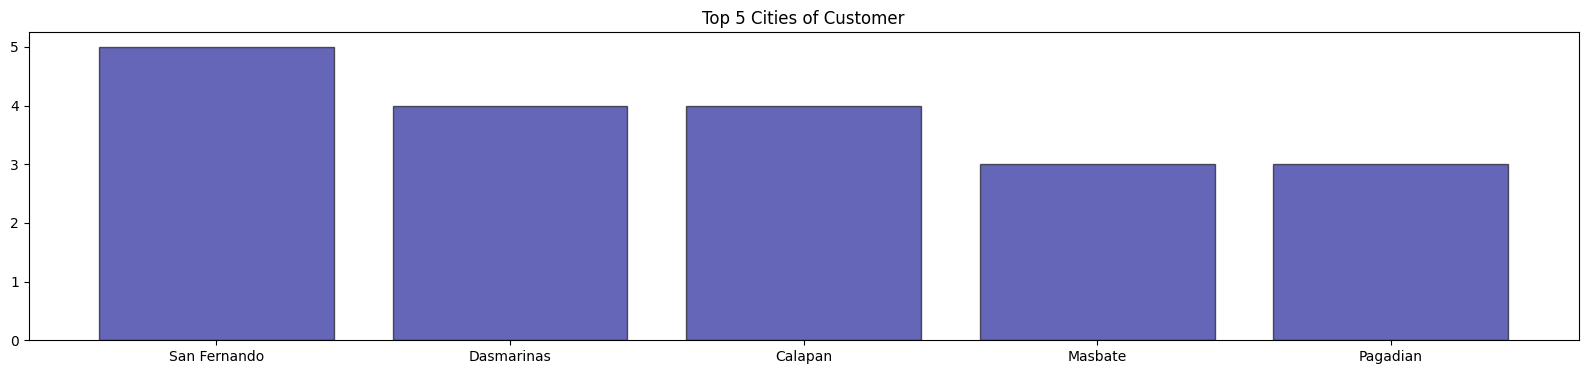

In [37]:
# Visual for Top Cities
plt.figure(figsize = (20,4))
plt.bar(city_pop_top5["city"], city_pop_top5["Customer_Count"], color = ["darkblue"], alpha = 0.6, edgecolor = "black")
plt.title("Top 5 Cities of Customer", fontsize = 12)


Key Points 

- San Fernando, Pampanga recorded the highest number of customers among all cities.
- From the Top 5 cities with the most cardholders, it is evident that all are located in Luzon, highlighting the region as the primary hub for cardholder concentration.

## Spending Behavior Analysis

In [39]:
# Sales Category
category = df_credit["category"].value_counts().head(10)
category

category
shopping_pos      6129
grocery_pos       6064
gas_transport     6059
kids_pets         5989
home              5855
personal_care     4808
food_dining       4699
entertainment     4610
misc_pos          3963
health_fitness    3245
Name: count, dtype: int64

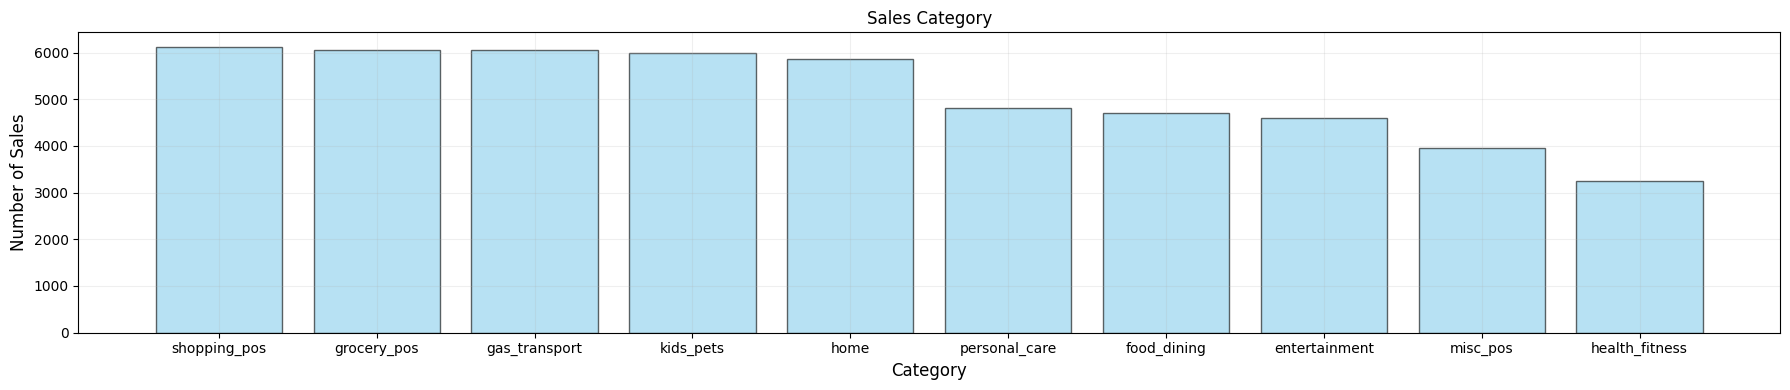

In [40]:
# visual for Sales Categorwy

plt.figure(figsize = (18,4))
plt.bar(category.index, category, color = ["skyblue"], alpha = 0.6, edgecolor = "Black")
plt.title("Sales Category", fontsize = 12)
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Number of Sales", fontsize = 12)
plt.grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()

Key Points 

- The Top 5 categories (shopping, grocery, gas/transport, kids/pets, home) each recorded ~5,000–6,000 sales, highlighting them as the primary drivers of consumer spending.
- The remaining categories fall below 5,000 sales, still showing solid demand, though not as dominant as the top tier.

In [41]:
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD,Age,Age_Bin
0,2.440000e+15,M,Masbate,95389,Social worker,1961-09-20,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84,64,50-70
1,4.090000e+15,M,Muntinlupa City,504509,Industrial/product designer,1938-12-04,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00,87,70-90
2,3.520000e+15,M,Digos,169393,"Administrator, charities/voluntary organisations",1970-08-31,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71,55,50-70
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",1945-05-28,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26,81,70-90
4,3.710000e+14,F,Maasin,85560,"Engineer, site",1966-04-18,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18,60,50-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",1960-08-02,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54,65,50-70
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,1949-10-25,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89,76,70-90
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,1966-11-01,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31,59,50-70
69998,3.470000e+14,M,Pagadian,199060,General practice doctor,1949-06-12,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28,77,70-90


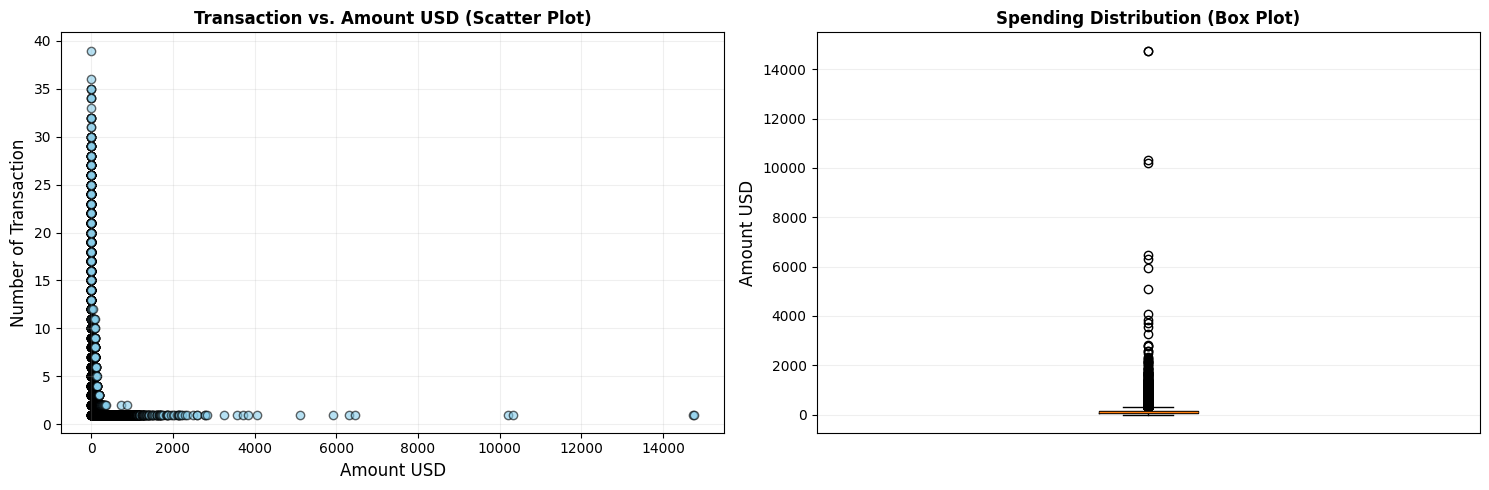

In [50]:
plt.figure(figsize = (15, 5))

# subplot 1: Transaction vs. Amount USD

plt.subplot(1,2,1)

# Aggregate Amount and Frequency
amount_counts = df_credit.groupby("amt_USD").size().reset_index(name = "Frequency")

amount_counts

#Visualize Transaction Amount Distribution

plt.scatter(amount_counts["amt_USD"],amount_counts["Frequency"], color = "skyblue", alpha = 0.6, edgecolor = "black")
plt.title('Transaction vs. Amount USD (Scatter Plot)', fontsize=12, fontweight='bold')
plt.xlabel("Amount USD", fontsize = 12)
plt.ylabel("Number of Transaction", fontsize = 12)
plt.grid(True, alpha = 0.2)

plt.tight_layout()


# subplot 2: Spending Distribution 

plt. subplot(1,2,2)
#Visualize Transaction Amount Distribution (boxplot for outliers)

plt.boxplot(amount_counts["amt_USD"])
plt.title('Spending Distribution (Box Plot)', fontsize=12, fontweight='bold')
plt.ylabel("Amount USD", fontsize = 12)
plt.xticks([])
plt.grid(True, alpha = 0.2)

plt.tight_layout()

Key Points 

- Typical spending range is very low (around $1–$10), shown by the small box near the bottom.
- Median is close to the lower end, confirming that most transactions are small.
- Numerous outliers appear far above the whisker — some reaching $14,000. This indicates a right‑skewed distribution where a few very large transactions stretch the scale.
- Outliers are not just single points — there are clusters of high‑value transactions, meaning these aren’t rare accidents but recurring patterns.

In [43]:
# Identify High Spent Outliers

spent_75th = df_credit["amt_USD"].quantile(0.75)
spent_q3_plus_iqr = spent_75th + (spent_75th - df_credit["amt_USD"].quantile(0.25)) * 1.5
high_spent = df_credit[df_credit["amt_USD"] > spent_q3_plus_iqr]

print(f"Addtional Spending Insights:")
print(f"We have {len(high_spent)} among all transactions showing recurring high spending")
print(f"This represents {(len(high_spent)/len(df_credit))*100:.1f}% of our spending base")


Addtional Spending Insights:
We have 2464 among all transactions showing recurring high spending
This represents 4.1% of our spending base


In [55]:
df_credit

,cc_num,gender,city,city_pop,job,dob,Acc_Number,trans_num,category,Transaction_date,amt_USD,Age,Age_Bin
0,2.440000e+15,M,Masbate,95389,Social worker,1961-09-20,786000000000,796378571728737b9c6fb9bce743f0b7,gas_transport,2020-03-24 16:12:38,82.84,64,50-70
1,4.090000e+15,M,Muntinlupa City,504509,Industrial/product designer,1938-12-04,722000000000,f19c0e584c1fd59bc115b74e20f40778,home,2021-11-02 01:55:15,56.00,87,70-90
2,3.520000e+15,M,Digos,169393,"Administrator, charities/voluntary organisations",1970-08-31,968000000000,6c6ee4e874bd6a2d8c9ee78e41f4d991,gas_transport,2021-05-28 11:38:47,42.71,55,50-70
3,4.730000e+15,M,Vigan,53879,"Geologist, engineering",1945-05-28,227000000000,e2f2c8b0de9ca20aa2e5e87e7eca8f3b,personal_care,2020-06-27 05:50:28,48.26,81,70-90
4,3.710000e+14,F,Maasin,85560,"Engineer, site",1966-04-18,994000000000,249ed34cd0370bf77e579955654548d6,entertainment,2020-05-15 08:41:10,8.18,60,50-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2.320000e+15,M,Binan,333028,"Teacher, early years/pre",1960-08-02,664000000000,99ac2ed7410025ff07dd3f579b519c3e,shopping_pos,2020-08-31 10:49:42,8.54,65,50-70
69996,3.540000e+15,M,Cabanatuan City,302231,Engineering geologist,1949-10-25,432000000000,6a863ad4e7a472ec9ac0e6cc346f85e8,misc_pos,2021-10-17 14:12:40,8.89,76,70-90
69997,4.010000e+12,M,Malaybalay,174625,Tourist information centre manager,1966-11-01,439000000000,2466d5a50c7dc8d363d0774022dee7f6,shopping_pos,2020-04-18 11:26:08,12.31,59,50-70
69998,3.470000e+14,M,Pagadian,199060,General practice doctor,1949-06-12,289000000000,169672de230b738c3f8c21b05bfdd4f1,health_fitness,2021-03-31 01:50:37,4.28,77,70-90


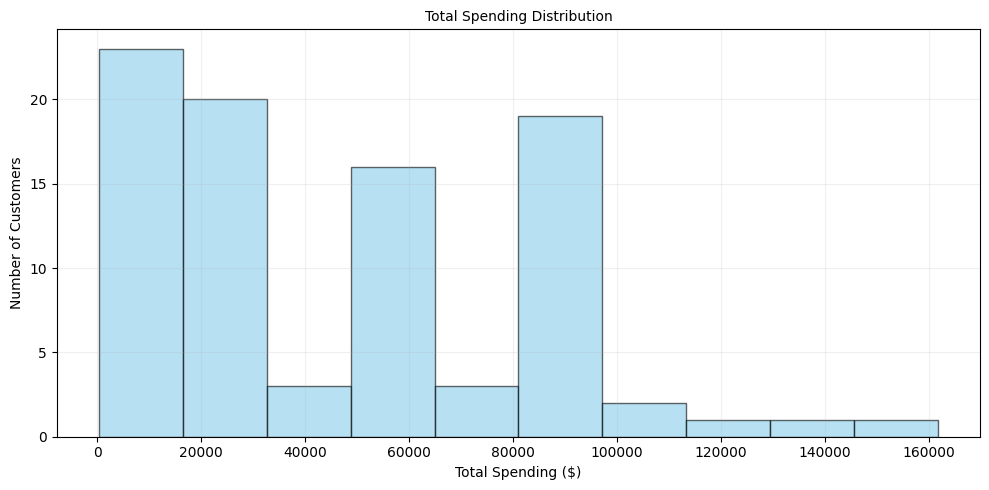

In [74]:
# know the total spending per card holder , make a histogram, to know the spending and number of customers

total_spending = df_credit.groupby("Acc_Number")["amt_USD"].sum().reset_index(name = "Amount_USD")
total_spending

plt.figure(figsize = (10,5))

plt.hist(total_spending["Amount_USD"], bins = 10, color = "skyblue", alpha = 0.6, edgecolor = "black")
plt.title("Total Spending Distribution", fontsize = 10)
plt.xlabel("Total Spending ($)", fontsize = 10)
plt.ylabel("Number of Customers", fontsize = 10)
plt.grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()



In [77]:
# we knwo number of sales per category , but we would also want to see the spending on the prodcut category

category_spending = df_credit.groupby("category")["amt_USD"].sum().reset_index(name = "Amount USD")
category_spending.sort_values(by = "Amount USD", ascending = False)

,category,Amount USD
4,grocery_pos,573371.93
7,kids_pets,479878.05
2,gas_transport,419170.41
12,shopping_pos,387439.19
1,food_dining,377037.47
11,shopping_net,364835.00
6,home,353752.81
0,entertainment,238778.08
9,misc_pos,237918.61
10,personal_care,213947.27
